## Data Loading and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


## Column Renaming

In [ ]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)


       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


## Checking for Missing Values and Duplicates

In [ ]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
<bound method DataFrame.sum of       country   year  population  continent  life_expectancy  gdp_per_capita
0       False  False       False      False            False           False
1       False  False       False      False            False           False
2       False  False       False      False            False           False
3       False  False       False      False            False           False
4       False  False       False      False            False           False
...       ...    ...         ...        ...              ...             ...
1699    False  False       False      False            False           False
1700    False  False       False      False            False           False
1701    False  False       False      False            False           False
1702    False  False       False      False            False           False
1703    False  False       False      False            False           False

[1704 rows x 

## Data Cleaning and Type Conversion

In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())



country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


## Demonstrating Missing Value Imputation

In [ ]:
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)


        country  year  population continent  life_expectancy  gdp_per_capita
0   Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1   Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2   Afghanistan  1962  10267083.0      Asia              NaN      853.100710
3   Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4   Afghanistan  1972  13079460.0      Asia           36.088      739.981106
5   Afghanistan  1977  14880372.0      Asia           38.438             NaN
6   Afghanistan  1982  12881816.0      Asia           39.854      978.011439
7   Afghanistan  1987  13867957.0      Asia           40.822      852.395945
8   Afghanistan  1992  16317921.0      Asia           41.674      649.341395
9   Afghanistan  1997  22227415.0      Asia           41.763      635.341351
10  Afghanistan  2002  25268405.0      Asia           42.129      726.734055
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338

## Data Cleaning and Summary Statistics (Countries and Continents)

In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

num_countries = df_clean['country'].nunique()
print(f"Number of countries in the dataset: {num_countries}")

Number of countries in the dataset: 142


In [ ]:
import pandas as pd

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df=pd.read_csv(url)

df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

num_countries = df_clean['country'].nunique()
num_continents = df_clean['continent'].nunique()

print(f"Number of countries in the dataset: {num_countries}")
print(f"Number of continents in the dataset: {num_continents}")

Number of countries in the dataset: 142
Number of continents in the dataset: 5


## Analyzing Year Range

In [ ]:
min_year = df['year'].min()
max_year = df['year'].max()

print("Year Range:", min_year, "-", max_year)

Year Range: 1952 - 2007


## Life Expectancy Statistics

In [ ]:
avg_life_expectancy = df_clean['life_expectancy'].mean()
min_life_expectancy = df_clean['life_expectancy'].min()
max_life_expectancy = df_clean['life_expectancy'].max()


print(f"The average life expectancy is: {avg_life_expectancy:.2f}")
print(f"The minimum life expectancy is: {min_life_expectancy:.2f}")
print(f"The maximum life expectancy is: {max_life_expectancy:.2f}")

The average life expectancy is: 59.47
The minimum life expectancy is: 23.60
The maximum life expectancy is: 82.60


## Visualization: Average Life Expectancy by Continent

/tmp/ipykernel_6529/2571486399.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='continent', y='life_expectancy', data=avg_life_expectancy_by_continent, palette='viridis')


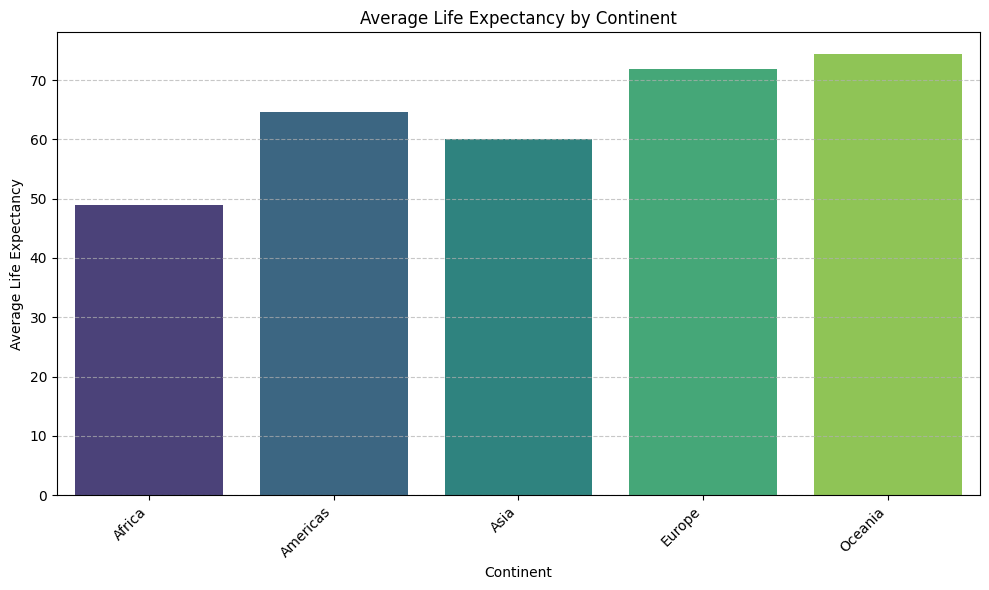

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_life_expectancy_by_continent = df_clean.groupby('continent')['life_expectancy'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='continent', y='life_expectancy', data=avg_life_expectancy_by_continent, palette='viridis')
plt.title('Average Life Expectancy by Continent')
plt.xlabel('Continent')
plt.ylabel('Average Life Expectancy')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualization: Life Expectancy Over Time (India, China, USA)

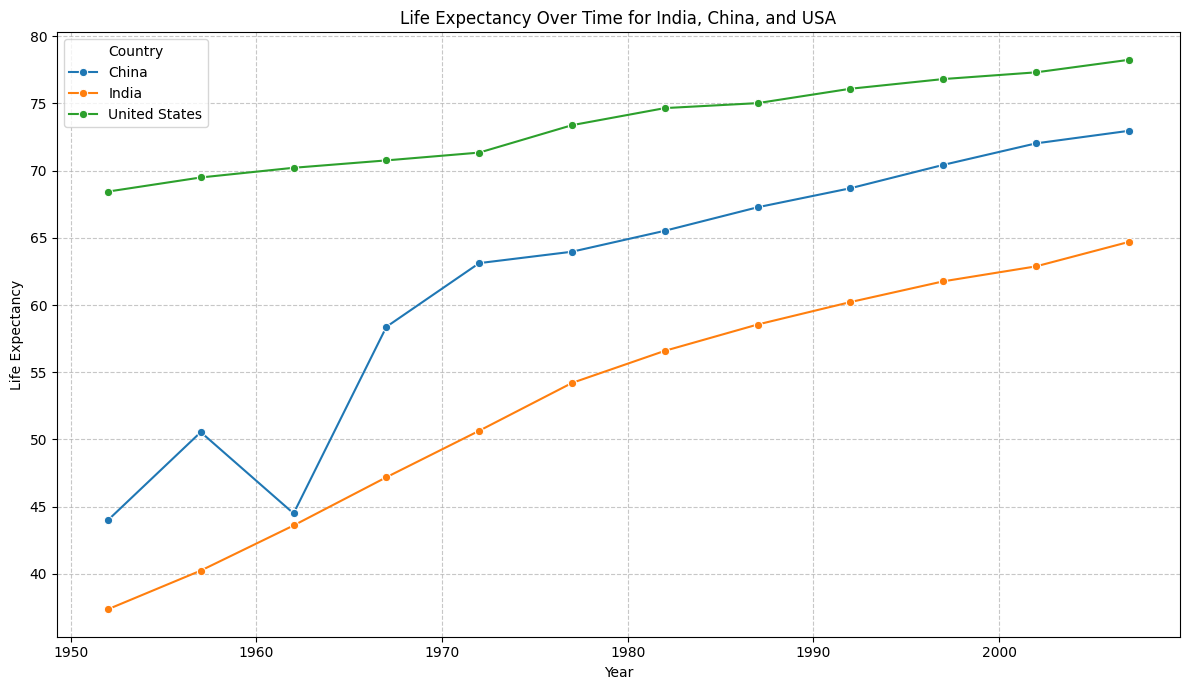

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for India, China, and USA
countries_to_plot = ['India', 'China', 'United States']
df_filtered = df_clean[df_clean['country'].isin(countries_to_plot)]

plt.figure(figsize=(12, 7))
sns.lineplot(x='year', y='life_expectancy', hue='country', data=df_filtered, marker='o')
plt.title('Life Expectancy Over Time for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

## Visualization: Life Expectancy vs. GDP Per Capita

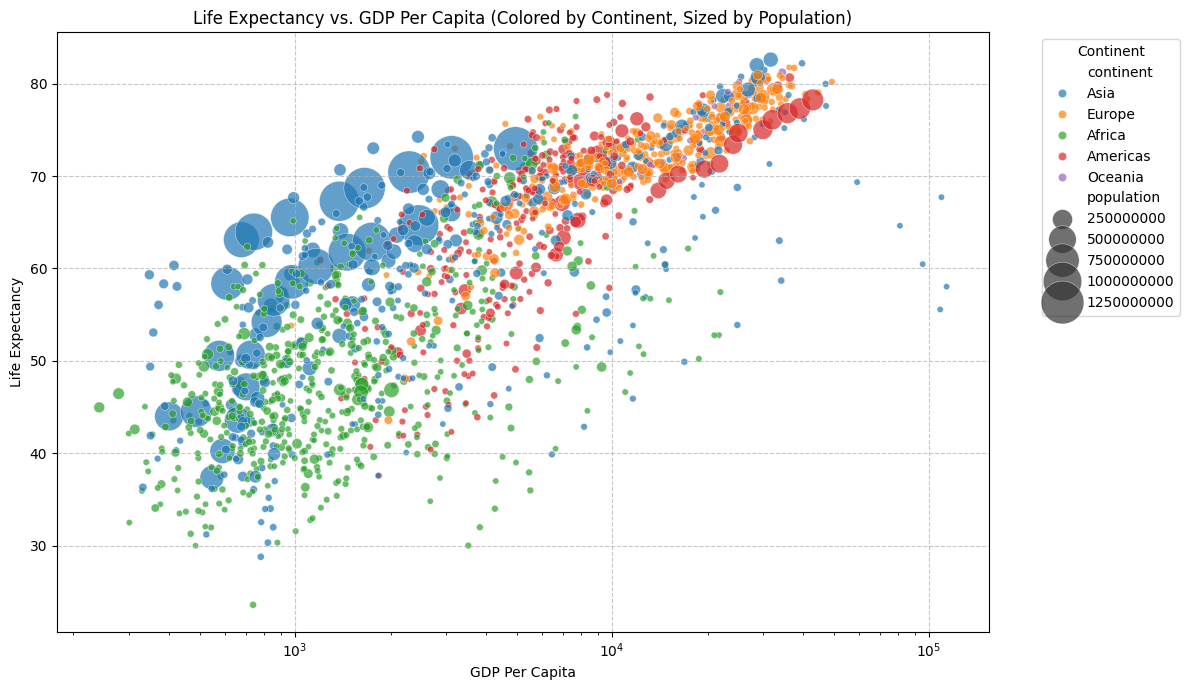

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x='gdp_per_capita', y='life_expectancy', data=df_clean, hue='continent', size='population', sizes=(20, 1000), alpha=0.7)
plt.title('Life Expectancy vs. GDP Per Capita (Colored by Continent, Sized by Population)')
plt.xlabel('GDP Per Capita')
plt.ylabel('Life Expectancy')
plt.xscale('log') # GDP per capita often has a skewed distribution, so a log scale can be helpful
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()